# DBSCAN Outlier Detection

DBSCAN finds dense groups and flags whatever fits nowhere as outliers. We run it twice on the first 100 recipes: once on ingredient text and once on nutritional columns.

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("dark_background")
BG = "#0F172A"; AMBER = "#F59E0B"; TEAL = "#14B8A6"; INK = "#E2E8F0"; RED = "#EF4444"
plt.rcParams.update({"figure.facecolor": BG, "axes.facecolor": BG,
                     "savefig.facecolor": BG, "text.color": INK,
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK})

recipes = pd.read_csv("../data/RAW_recipes_processed.csv")
ingredients = recipes["ingredients"].dropna()
print("recipes loaded:", recipes.shape[0])

from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize(texts, ngram_range=(1, 2), max_features=1000):
    vec = TfidfVectorizer(max_df=0.5, max_features=max_features, min_df=2,
                          stop_words="english", ngram_range=ngram_range, use_idf=True)
    return vec.fit_transform(texts), vec
from sklearn.decomposition import PCA
X100, _ = vectorize(ingredients.values[:100])
p100 = PCA(n_components=2).fit_transform(X100.toarray())
names100 = recipes["name"].iloc[:100].tolist()
print("text PCA shape:", p100.shape)

recipes loaded: 10000
text PCA shape: (100, 2)


elbow sits near 0.145, so eps=0.145 with min samples=5


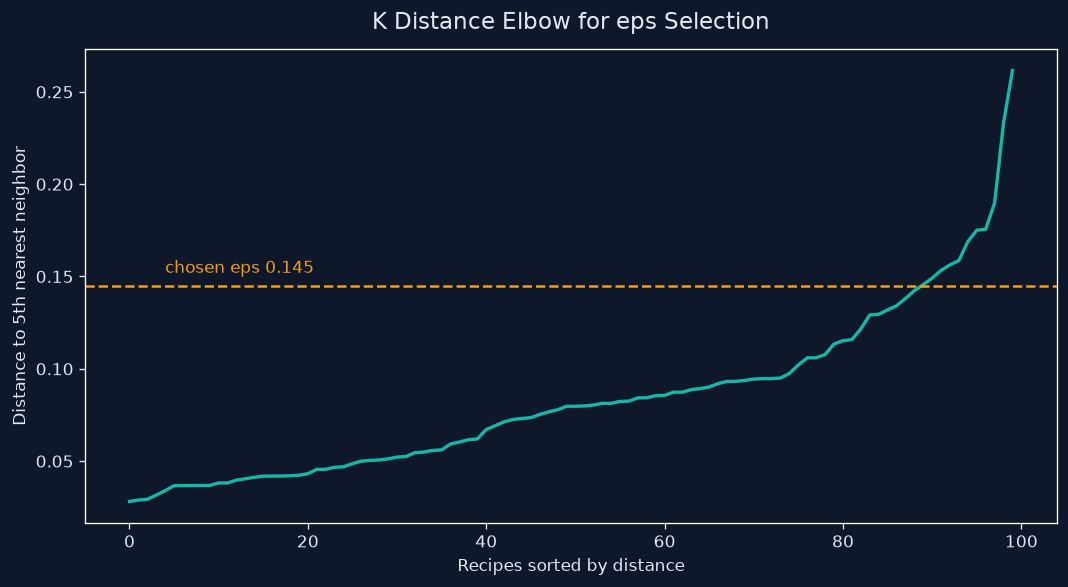

In [2]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5).fit(p100)
kdist = np.sort(nn.kneighbors(p100)[0][:, 4])
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(kdist, color=TEAL, linewidth=2)
ax.axhline(0.145, color=AMBER, linestyle="--", linewidth=1.5)
ax.text(4, 0.152, "chosen eps 0.145", color=AMBER, fontsize=10)
ax.set_title("K Distance Elbow for eps Selection", fontsize=14, pad=12)
ax.set_xlabel("Recipes sorted by distance")
ax.set_ylabel("Distance to 5th nearest neighbor")
fig.tight_layout()
fig.savefig("../charts/chart_kdistance_elbow.png", dpi=120)
print("elbow sits near 0.145, so eps=0.145 with min samples=5")

In [3]:
from sklearn.cluster import DBSCAN
text_labels = DBSCAN(eps=0.145, min_samples=5).fit_predict(p100)
text_out = np.where(text_labels == -1)[0]
print("text outliers:", len(text_out))
for i in text_out:
    print(" *", names100[i])

text outliers: 4
 * more  more    apple pear jigglers
 * no bake  cookie crumble cheesecake
 * the best  chocolate chip cheesecake ever
 * the man s  taco dip


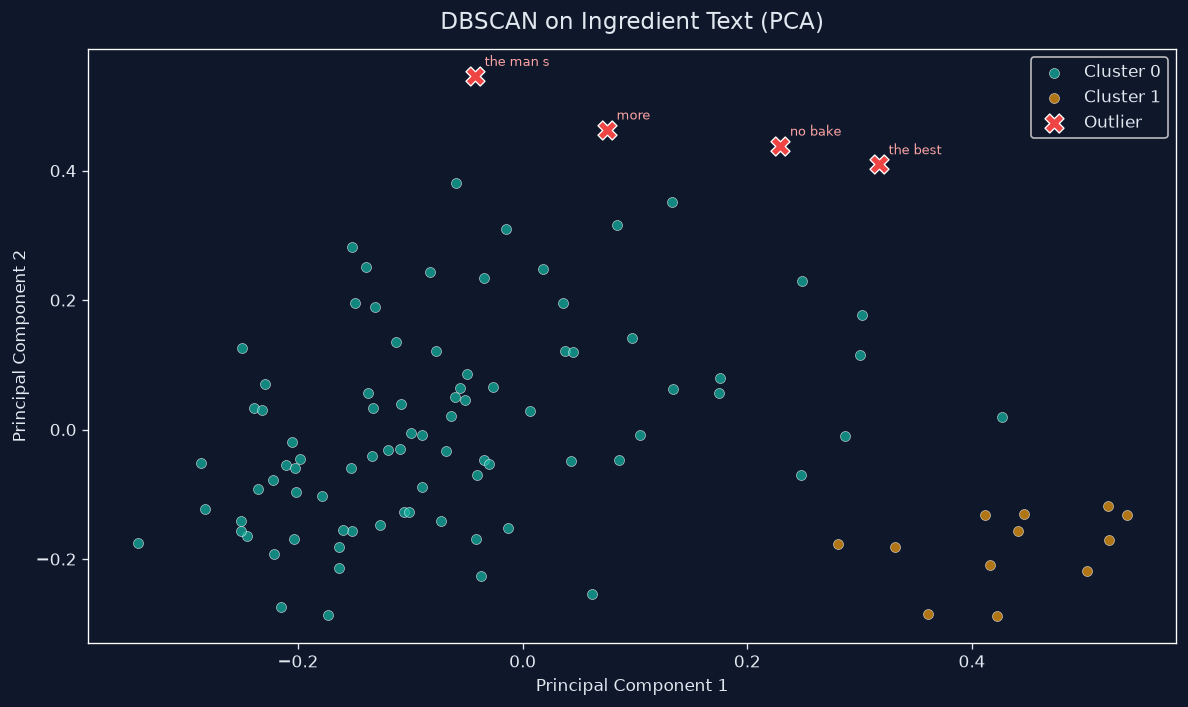

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(p100[text_labels == 0, 0], p100[text_labels == 0, 1], s=36, alpha=0.7,
            color=TEAL, label="Cluster 0", edgecolor="white", linewidth=0.4)
ax.scatter(p100[text_labels == 1, 0], p100[text_labels == 1, 1], s=36, alpha=0.7,
            color=AMBER, label="Cluster 1", edgecolor="white", linewidth=0.4)
ax.scatter(p100[text_out, 0], p100[text_out, 1], s=130, marker="X",
            color=RED, label="Outlier", edgecolor="white", linewidth=0.8)
for i in text_out:
    ax.annotate(names100[i].split("  ")[0][:22], (p100[i, 0], p100[i, 1]),
                xytext=(6, 6), textcoords="offset points", fontsize=8, color="#FCA5A5")
ax.set_title("DBSCAN on Ingredient Text (PCA)", fontsize=14, pad=12)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(framealpha=0.9)
fig.tight_layout()
fig.savefig("../charts/chart_dbscan_text.png", dpi=120)

In [5]:
from sklearn.preprocessing import StandardScaler
fields = ["calories", "total_fat_pdv", "sugar_pdv", "sodium_pdv",
          "protein_pdv", "saturated_fat_pdv", "carbs_pdv"]
nut_pca = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(recipes[fields].iloc[:100]))
nut_labels = DBSCAN(eps=1.0, min_samples=5).fit_predict(nut_pca)
nut_out = np.where(nut_labels == -1)[0]
print("nutrition outliers:", len(nut_out))
for i in nut_out:
    print(" *", names100[i])

nutrition outliers: 11
 * backyard style  barbecued ribs
 * bananas 4 ice cream  pie
 * beat this  banana bread
 * deep fried dessert thingys
 * easiest ever  hollandaise sauce
 * jeanne s style  birthday cake
 * love is in the air  beef fondue   sauces
 * one pot  brownies
 * spicy  banana bread
 * symphony  brownies
 * the best  chocolate chip cheesecake ever


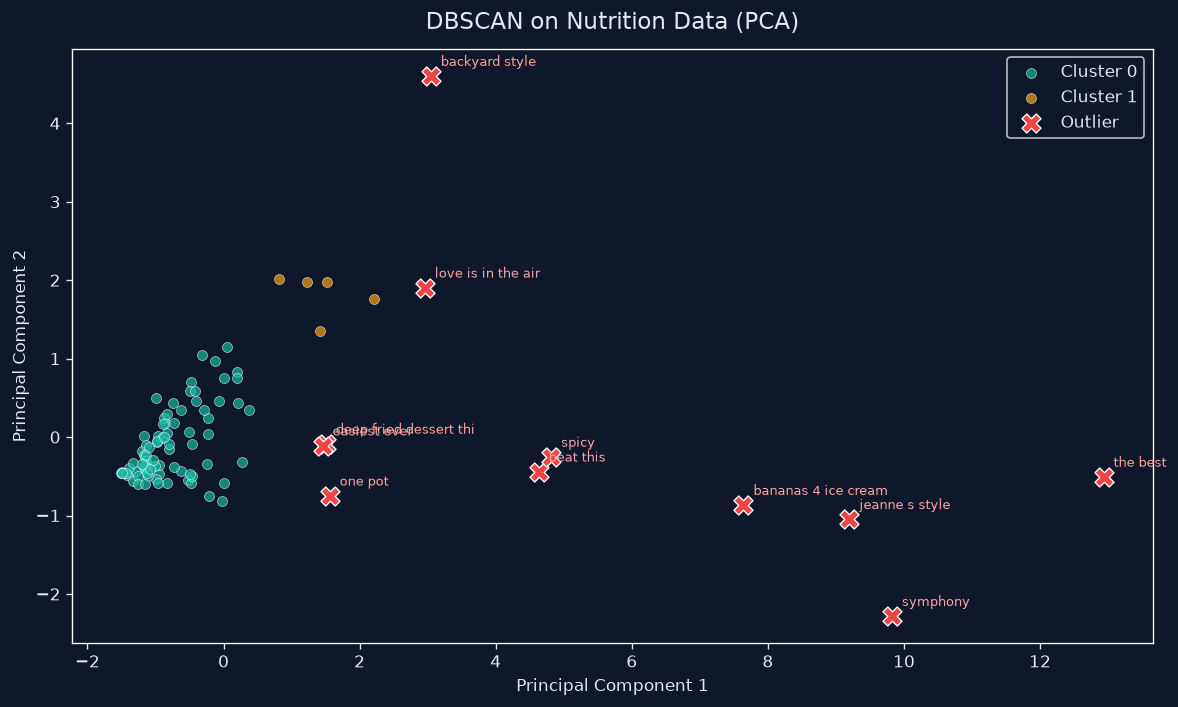

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(nut_pca[nut_labels == 0, 0], nut_pca[nut_labels == 0, 1], s=36, alpha=0.7,
            color=TEAL, label="Cluster 0", edgecolor="white", linewidth=0.4)
ax.scatter(nut_pca[nut_labels == 1, 0], nut_pca[nut_labels == 1, 1], s=36, alpha=0.7,
            color=AMBER, label="Cluster 1", edgecolor="white", linewidth=0.4)
ax.scatter(nut_pca[nut_out, 0], nut_pca[nut_out, 1], s=130, marker="X",
            color=RED, label="Outlier", edgecolor="white", linewidth=0.8)
for i in nut_out:
    ax.annotate(names100[i].split("  ")[0][:22], (nut_pca[i, 0], nut_pca[i, 1]),
                xytext=(6, 6), textcoords="offset points", fontsize=8, color="#FCA5A5")
ax.set_title("DBSCAN on Nutrition Data (PCA)", fontsize=14, pad=12)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(framealpha=0.9)
fig.tight_layout()
fig.savefig("../charts/chart_dbscan_nutrition.png", dpi=120)

## Findings

* Text view: 4 outliers. Gelatin desserts, two cheesecakes and a taco dip sit far from every dense group.
* Nutrition view: 11 outliers. Mostly rich desserts, fried food and heavy sauces with extreme calorie or fat numbers.
* Two recipes are outliers in both views: bananas 4 ice cream pie and the best chocolate chip cheesecake ever. Extreme ingredients and extreme nutrition go together.
* DBSCAN needed no K up front. It found 2 dense groups per view and let the odd ones out speak for themselves.